In [84]:
# Config
from pathlib import Path
import os

# Input: root directory containing subdirectories for models
# Only models with training_summary.json (and not named 'resnet10t.c3_in1k') are used
MODELS_ROOT = '../training_gradient_evaluator_single_loss/outputs_subset_of_8_lr_0.0001_1500_examples/'
CSV_NAME = 'single_example_results.csv'
REQUIRED_JSON = 'training_summary.json'
EXCLUDE_DIR_NAMES = {''}

SEED = 1338
TEST_SIZE = 0.10  # of total dataset
VAL_SIZE = 0.05   # of total dataset (normalized after test split)
TARGET_COLUMN = 'universal_difficulty_rank'
# Per-model metrics to collect
BASE_FEATURE_COLUMNS = [
    'total_steps_to_epsilon',
    'total_loss_sum',
    'final_loss',
    'weight_distance',
    'softmax_wasserstein',
    'grad_mass_wasserstein',
    'global_linear_cka',
]
SAVE_MODELS = True
ARTIFACTS_DIRNAME = 'rank_predictor_artifacts_multi'

In [85]:
# Lower/Upper fraction bounds (by existing row order)
LOWER_FRACTION = 0.0  # inclusive start fraction
UPPER_FRACTION = 1.0  # exclusive end fraction

In [86]:
# Imports
import json
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib
import matplotlib.pyplot as plt

random.seed(SEED)
np.random.seed(SEED)


In [87]:
# Discovery and loading utilities

def find_eligible_model_dirs(root: str | Path,
                           csv_name: str = CSV_NAME,
                           required_json: str = REQUIRED_JSON,
                           exclude_dirs: set[str] = EXCLUDE_DIR_NAMES) -> dict[str, Path]:
	root = Path(root)
	model_csvs: dict[str, Path] = {}
	if not root.exists():
		raise FileNotFoundError(f"Root not found: {root}")
	for sub in sorted(root.iterdir()):
		if not sub.is_dir():
			continue
		if sub.name in exclude_dirs:
			continue
		json_path = sub / required_json
		csv_path = sub / csv_name
		if json_path.exists() and csv_path.exists():
			model_csvs[sub.name] = csv_path
	return model_csvs


def load_model_csv(csv_path: Path,
                 base_feature_cols: list[str],
                 target_col: str,
                 id_cols: list[str] = ['example_index', 'path']) -> pd.DataFrame:
	"""Load a single model csv with selected columns only.
	Adds only the columns we need to minimize memory, keeps id and target.
	"""
	df = pd.read_csv(csv_path)
	keep_cols = list(dict.fromkeys(id_cols + base_feature_cols + [target_col]))
	for c in keep_cols:
		if c not in df.columns:
			df[c] = np.nan
	return df[keep_cols].copy()


def wide_merge_by_example(model_to_df: dict[str, pd.DataFrame],
                        base_feature_cols: list[str],
                        target_col: str) -> pd.DataFrame:
	"""Outer-merge per model by example_index; suffix feature columns per model.
	- Keep target only once (from the first frame that has it).
	- Keep a single canonical path column (from the first frame only).
	"""
	merged: pd.DataFrame | None = None
	target_kept = False
	for i, (model_name, df) in enumerate(model_to_df.items()):
		# Prepare suffix mapping for features
		renamed = df.copy()
		feature_renames = {c: f"{c}__{model_name}" for c in base_feature_cols}
		renamed = renamed.rename(columns=feature_renames)
		cols_to_use = ['example_index']
		# include path only for the first model to avoid collisions
		if i == 0 and 'path' in renamed.columns:
			cols_to_use.append('path')
		cols_to_use += list(feature_renames.values())
		# include target only once
		if not target_kept and target_col in df.columns:
			cols_to_use.append(target_col)
			target_kept = True
		renamed = renamed[cols_to_use]
		if merged is None:
			merged = renamed
		else:
			merged = pd.merge(merged, renamed, on=['example_index'], how='outer')
	if merged is None:
		return pd.DataFrame()
	# Ensure target present if none provided
	if target_col not in merged.columns:
		merged[target_col] = np.nan
	return merged



In [88]:
# Modeling utilities (reuse from single-model style)

def build_regressors(seed: int):
	models = {
		"hgb": HistGradientBoostingRegressor(random_state=seed, max_depth=None, learning_rate=0.05, max_iter=700),
		"rf": RandomForestRegressor(random_state=seed, n_estimators=800, max_depth=None, n_jobs=-1, oob_score=False),
		"xgb": XGBRegressor(
			random_state=seed,
			n_estimators=900,
			max_depth=8,
			learning_rate=0.05,
			subsample=0.8,
			colsample_bytree=0.8,
			tree_method='hist',
			reg_lambda=1.0,
		),
		"ridge": Ridge(random_state=seed),
		"elasticnet": ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=seed, max_iter=20000),
		"catboost": CatBoostRegressor(depth=8, learning_rate=0.03, n_estimators=1200, subsample=0.8, loss_function='RMSE', random_state=seed, verbose=False),
	}
	return models


def build_pipeline(estimator, numeric_features: list[str]) -> Pipeline:
	preprocess = ColumnTransformer(
		transformers=[
			("num", Pipeline(steps=[
				("imputer", SimpleImputer(strategy="median")),
				("scaler", StandardScaler()),
			]), numeric_features),
		], remainder='drop'
	)
	pipe = Pipeline(steps=[
		("preprocess", preprocess),
		("regressor", estimator),
	])
	return pipe


def evaluate_model(model: Pipeline, X: pd.DataFrame, y: np.ndarray) -> dict:
	pred = model.predict(X)
	mae = float(mean_absolute_error(y, pred))
	r2 = float(r2_score(y, pred))
	return {"mae": mae, "r2": r2}


def fit_and_select(train_df: pd.DataFrame, val_df: pd.DataFrame, feature_cols: list[str], target_col: str, seed: int):
	models = build_regressors(seed)
	metrics = {}
	best_name = None
	best_score = float('inf')
	best_model = None
	for name, est in models.items():
		pipe = build_pipeline(est, feature_cols)
		pipe.fit(train_df[feature_cols], train_df[target_col].values)
		m = evaluate_model(pipe, val_df[feature_cols], val_df[target_col].values)
		metrics[name] = m
		if m["mae"] < best_score:
			best_score = m["mae"]
			best_name = name
			best_model = pipe
	return best_name, best_model, metrics


Scanning models in: ../training_gradient_evaluator_single_loss/outputs_subset_of_8_lr_0.0001_1500_examples/
Found 5 eligible models
  - efficientvit_b1.r224_in1k: ..\training_gradient_evaluator_single_loss\outputs_subset_of_8_lr_0.0001_1500_examples\efficientvit_b1.r224_in1k\single_example_results.csv
  - efficientvit_b2.r224_in1k: ..\training_gradient_evaluator_single_loss\outputs_subset_of_8_lr_0.0001_1500_examples\efficientvit_b2.r224_in1k\single_example_results.csv
  - resnet10t.c3_in1k: ..\training_gradient_evaluator_single_loss\outputs_subset_of_8_lr_0.0001_1500_examples\resnet10t.c3_in1k\single_example_results.csv
  - resnet18.gluon_in1k: ..\training_gradient_evaluator_single_loss\outputs_subset_of_8_lr_0.0001_1500_examples\resnet18.gluon_in1k\single_example_results.csv
  - resnet18.tv_in1k: ..\training_gradient_evaluator_single_loss\outputs_subset_of_8_lr_0.0001_1500_examples\resnet18.tv_in1k\single_example_results.csv
Merged shape: (1500, 38)
Rows with target present: 1500
Usi

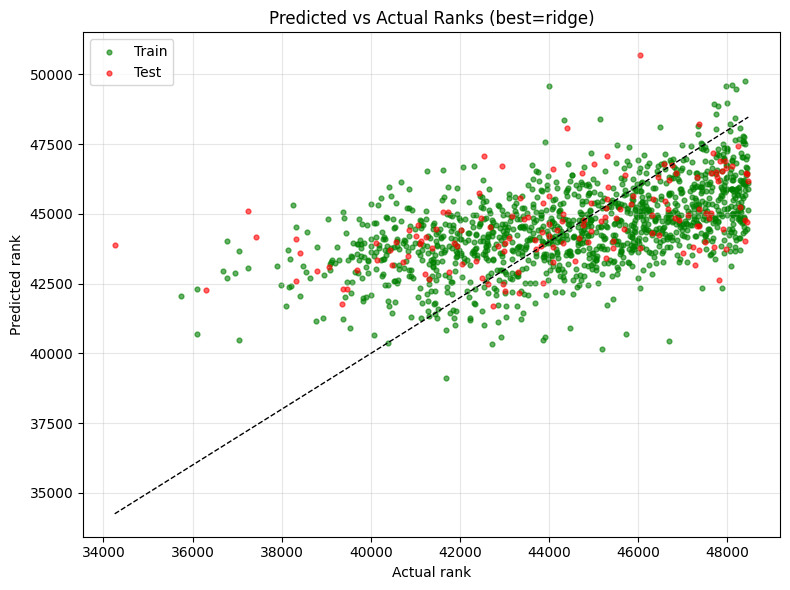

{'models_root': '../training_gradient_evaluator_single_loss/outputs_subset_of_8_lr_0.0001_1500_examples/',
 'best_model': 'ridge',
 'metrics': {'hgb': {'mae': 2149.6904800958723, 'r2': -0.24378887371332625},
  'rf': {'mae': 1932.6835333333336, 'r2': -0.023154481952409434},
  'xgb': {'mae': 2044.75732421875, 'r2': -0.09294092655181885},
  'ridge': {'mae': 1886.8606221569678, 'r2': 0.015992997249997698},
  'elasticnet': {'mae': 1886.911119098044, 'r2': 0.015886580009526474},
  'catboost': {'mae': 1913.23569073195, 'r2': -0.005108612308417415},
  'test': {'mae': 2036.711515630295, 'r2': 0.24443347833815088}},
 'num_features': 35}

In [89]:
# End-to-end: scan, merge, train, evaluate, save

def build_feature_list_from_merged(merged: pd.DataFrame, base_cols: list[str]) -> list[str]:
	feat_cols = []
	for c in merged.columns:
		if any(c.startswith(f+"__") for f in base_cols):
			feat_cols.append(c)
	return sorted(feat_cols)


def split_train_val_test(df: pd.DataFrame, test_size: float, val_size: float, seed: int):
	train_val, test = train_test_split(df, test_size=test_size, random_state=seed, shuffle=True)
	val_rel = val_size / max(1e-9, (1.0 - test_size))
	train, val = train_test_split(train_val, test_size=val_rel, random_state=seed, shuffle=True)
	return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


def save_artifacts(model_root: Path, best_name: str, model: Pipeline, metrics: dict, feature_cols: list[str]) -> None:
	art_dir = Path(model_root) / ARTIFACTS_DIRNAME
	art_dir.mkdir(parents=True, exist_ok=True)
	joblib.dump(model, art_dir / f"best_model_{best_name}.joblib")
	with open(art_dir / "metrics.json", 'w', encoding='utf-8') as f:
		json.dump(metrics, f, indent=2)
	with open(art_dir / "features.json", 'w', encoding='utf-8') as f:
		json.dump({"feature_columns": feature_cols, "target": TARGET_COLUMN}, f, indent=2)


def plot_pred_vs_actual(train_df, test_df, train_pred, test_pred, target_col: str, best_name: str, out_dir: Path | None = None):
	plt.figure(figsize=(8, 6))
	plt.scatter(train_df[target_col].values, train_pred, s=12, alpha=0.6, c='green', label='Train')
	plt.scatter(test_df[target_col].values, test_pred, s=12, alpha=0.6, c='red', label='Test')
	min_r = float(min(train_df[target_col].min(), test_df[target_col].min()))
	max_r = float(max(train_df[target_col].max(), test_df[target_col].max()))
	plt.plot([min_r, max_r], [min_r, max_r], 'k--', linewidth=1)
	plt.xlabel('Actual rank')
	plt.ylabel('Predicted rank')
	plt.title(f'Predicted vs Actual Ranks (best={best_name})')
	plt.legend()
	plt.grid(True, alpha=0.3)
	plt.tight_layout()
	if out_dir is not None:
		out_dir.mkdir(parents=True, exist_ok=True)
		plt.savefig(out_dir / 'pred_vs_actual.png', dpi=150)
	plt.show()


def run_multi_model_training(models_root: str | Path = MODELS_ROOT,
							   base_feature_cols: list[str] = BASE_FEATURE_COLUMNS,
							   target_col: str = TARGET_COLUMN,
							   seed: int = SEED,
							   test_size: float = TEST_SIZE,
							   val_size: float = VAL_SIZE,
							   save_models: bool = SAVE_MODELS,
							   lower_fraction: float = LOWER_FRACTION,
							   upper_fraction: float = UPPER_FRACTION):
	print(f"Scanning models in: {models_root}")
	model_map = find_eligible_model_dirs(models_root, CSV_NAME, REQUIRED_JSON, EXCLUDE_DIR_NAMES)
	print(f"Found {len(model_map)} eligible models")
	for m, p in model_map.items():
		print(f"  - {m}: {p}")
	# Load all
	per_model_dfs: dict[str, pd.DataFrame] = {}
	for model_name, csvp in model_map.items():
		per_model_dfs[model_name] = load_model_csv(csvp, base_feature_cols, target_col)
	if not per_model_dfs:
		print("No eligible models found.")
		return None
	merged = wide_merge_by_example(per_model_dfs, base_feature_cols, target_col)
	print(f"Merged shape: {merged.shape}")
	# Restrict to rows with target present
	merged = merged.dropna(subset=[target_col])
	print(f"Rows with target present: {len(merged)}")
	if merged.empty:
		print("No data with target.")
		return None
	# Apply lower/upper fraction slicing by existing row order
	lo = float(max(0.0, min(1.0, lower_fraction)))
	up = float(max(0.0, min(1.0, upper_fraction)))
	if up < lo:
		lo, up = up, lo
	start = int(math.floor(len(merged) * lo))
	end = int(math.floor(len(merged) * up))
	merged = merged.iloc[start:end].reset_index(drop=True)
	print(f"Using slice [{lo:.2f}, {up:.2f}) -> rows: {len(merged)} (start={start}, end={end})")
	feature_cols = build_feature_list_from_merged(merged, base_feature_cols)
	print(f"Total feature columns: {len(feature_cols)}")
	# Split
	train_df, val_df, test_df = split_train_val_test(merged, test_size, val_size, seed)
	print(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
	# Fit and select
	best_name, best_model, metrics = fit_and_select(train_df, val_df, feature_cols, target_col, seed)
	print("All validation metrics by model:")
	for name, m in metrics.items():
		print(f"  {name}: MAE={m['mae']:.4f}, R2={m['r2']:.4f}")
	# Evaluate on test and correlations
	test_metrics = evaluate_model(best_model, test_df[feature_cols], test_df[target_col].values)
	metrics['test'] = test_metrics
	print(f"Best model on val: {best_name}")
	print(f"Test metrics: MAE={test_metrics['mae']:.4f}, R2={test_metrics['r2']:.4f}")
	from scipy.stats import pearsonr
	train_pred = best_model.predict(train_df[feature_cols])
	test_pred = best_model.predict(test_df[feature_cols])
	train_r, _ = pearsonr(train_df[target_col].values, train_pred)
	test_r, _ = pearsonr(test_df[target_col].values, test_pred)
	print(f"Correlation (train): r={float(train_r):.4f}")
	print(f"Correlation (test):  r={float(test_r):.4f}")
	# Per-1,000-bin average absolute error (by true rank)
	bin_size = 1000
	def _binned_mae(df: pd.DataFrame, pred: np.ndarray) -> pd.DataFrame:
		arr = pd.DataFrame({
			'y': df[target_col].values.astype(np.int64),
			'err': np.abs(pred - df[target_col].values),
		})
		arr['bin'] = (arr['y'] // bin_size).astype(int)
		return arr
	train_bins = _binned_mae(train_df, train_pred)
	test_bins = _binned_mae(test_df, test_pred)
	all_bins = sorted(set(train_bins['bin'].unique()).union(set(test_bins['bin'].unique())))
	print("Average absolute error per 1,000-rank bin (by true rank):")
	for b in all_bins:
		lo = b * bin_size
		hi = (b + 1) * bin_size
		tr = train_bins.loc[train_bins['bin'] == b, 'err']
		te = test_bins.loc[test_bins['bin'] == b, 'err']
		mae_tr = float(tr.mean()) if len(tr) else float('nan')
		mae_te = float(te.mean()) if len(te) else float('nan')
		print(f"  [{lo:6d}-{hi:6d}): train_MAE={mae_tr:.2f} (n={len(tr)}), test_MAE={mae_te:.2f} (n={len(te)})")
	# Plot and save
	art_dir = Path(models_root) / ARTIFACTS_DIRNAME
	plot_pred_vs_actual(train_df, test_df, train_pred, test_pred, target_col, best_name, out_dir=(art_dir if save_models else None))
	if save_models and best_model is not None:
		save_artifacts(models_root, best_name, best_model, metrics, feature_cols)
	return {"models_root": str(models_root), "best_model": best_name, "metrics": metrics, "num_features": len(feature_cols)}

# Run
run_multi_model_training(MODELS_ROOT)
